In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2774


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_6484/1359281906.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  secchi_dates["Year"] = pd.to_datetime(secchi_dates["Date"]).dt.year


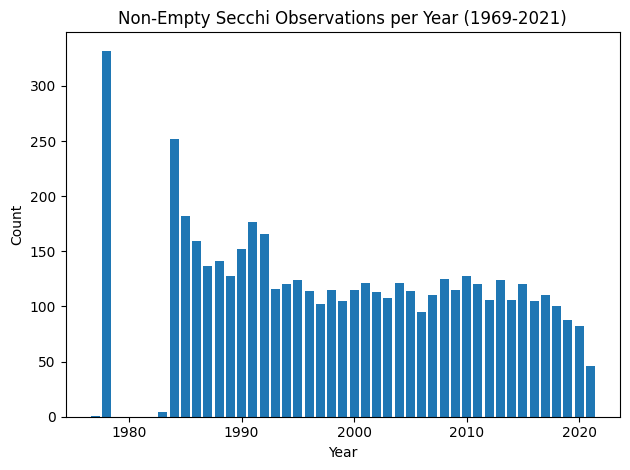

In [23]:
sechi_non_empty = df.loc[df["Secchi"].notna(), "Date"]
print(len(sechi_non_empty))

secchi_dates = pd.read_csv("../../data/secchi_non_empty_dates.csv")
secchi_dates["Year"] = pd.to_datetime(secchi_dates["Date"]).dt.year
year_counts = secchi_dates[secchi_dates["Year"].between(1969, 2021)].groupby("Year").size()

plt.figure()
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Non-Empty Secchi Observations per Year (1969-2021)")
plt.tight_layout()
plt.show()

In [ ]:
# data is stored outside of repository folder in order to keep it out of the repo
df = pd.read_parquet('../../data/merged_dataset_organized.parquet')
print(df.head())
print(df.columns)

   ORD_OCC    CAST_ID         DATE_TIME_UTC         DATE_TIME_PST  LAT_DEC  \
0      1.0  9308_001d  1993-08-11T12:05:46Z  1993-08-11T04:05:46Z      NaN   
1      1.0  9308_001d  1993-08-11T12:06:04Z  1993-08-11T04:06:04Z    -99.0   
2      1.0  9308_001d  1993-08-11T12:06:10Z  1993-08-11T04:06:10Z    -99.0   
3      1.0  9308_001d  1993-08-11T12:06:11Z  1993-08-11T04:06:11Z    -99.0   
4      1.0  9308_001d  1993-08-11T12:06:14Z  1993-08-11T04:06:14Z    -99.0   

   LON_DEC       STA_ID  DEPTH  PRESSURE  TEMP1  ...  Secchi  IntChl  IntC14  \
0      NaN  093.3 026.7    2.0      2.01  20.98  ...     NaN     NaN     NaN   
1    -99.0  093.3 026.7    3.0      3.02  20.89  ...     NaN     NaN     NaN   
2    -99.0  093.3 026.7    4.0      4.02  20.81  ...     NaN     NaN     NaN   
3    -99.0  093.3 026.7    5.0      5.03  20.69  ...     NaN     NaN     NaN   
4    -99.0  093.3 026.7    6.0      6.04  20.68  ...     NaN     NaN     NaN   

   TimeZone  Wave_Dir  Wave_Ht  Wave_Prd  Wind_Dir

### Our effective data range is from 8/11/93 to 5/6/2021
Downcast CTD calCOFI data first date: 1993-08-11T04:05:46Z

Secchi depth last date: 5/6/2021

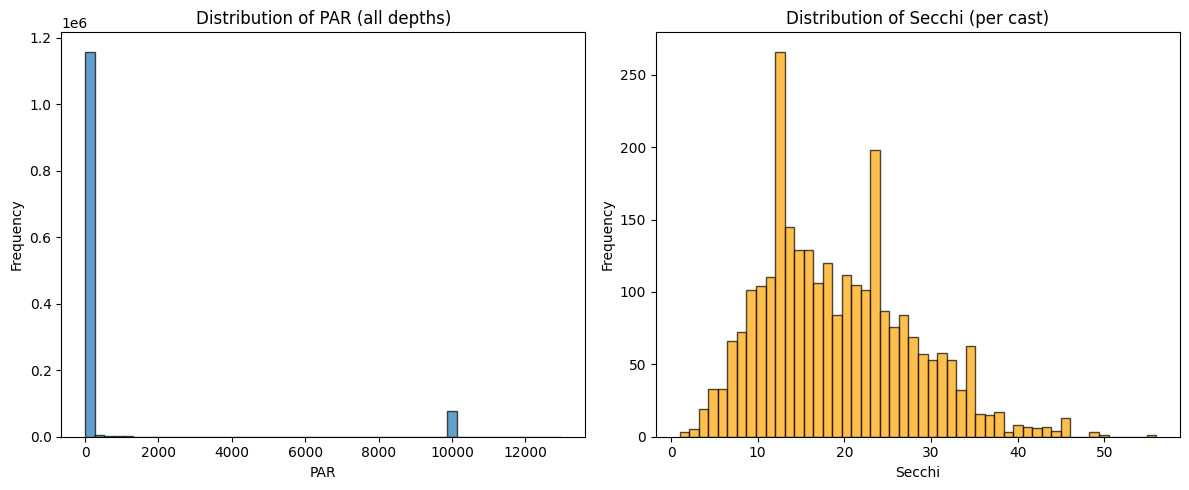

In [14]:
# Distribution comparison of PAR and Secchi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PAR distribution (all values across depths)
axes[0].hist(df['PAR'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('PAR')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of PAR (all depths)')

# Secchi distribution (one per CAST_COUNT)
secchi_per_cast = df.groupby('CAST_COUNT')['Secchi'].first()
axes[1].hist(secchi_per_cast.dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Secchi')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Secchi (per cast)')

plt.tight_layout()
plt.show()

In [15]:
par_agg = df.groupby('CAST_COUNT')['PAR'].agg(['mean', 'max', 'min']).rename(
    columns={'mean': 'PAR_mean', 'max': 'PAR_max', 'min': 'PAR_min'}
)
secchi_agg = df.groupby('CAST_COUNT')['Secchi'].first()

# Combine for correlation
corr_df = par_agg.join(secchi_agg).dropna()

print(f"\nCorrelation between Secchi and PAR metrics (n={len(corr_df)} casts):")
print(corr_df.corr()['Secchi'])


Correlation between Secchi and PAR metrics (n=2774 casts):
PAR_mean   -0.038932
PAR_max     0.054694
PAR_min    -0.025560
Secchi      1.000000
Name: Secchi, dtype: float64


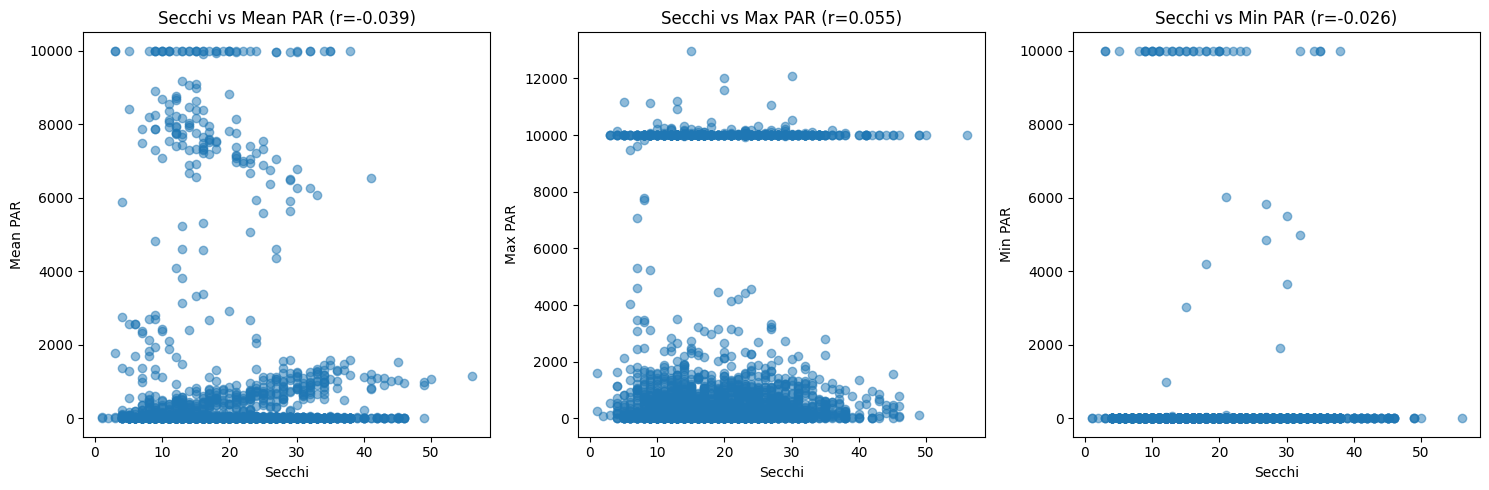

In [16]:
# Scatter plot: Secchi vs mean PAR
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(corr_df['Secchi'], corr_df['PAR_mean'], alpha=0.5)
axes[0].set_xlabel('Secchi')
axes[0].set_ylabel('Mean PAR')
axes[0].set_title(f"Secchi vs Mean PAR (r={corr_df['Secchi'].corr(corr_df['PAR_mean']):.3f})")

axes[1].scatter(corr_df['Secchi'], corr_df['PAR_max'], alpha=0.5)
axes[1].set_xlabel('Secchi')
axes[1].set_ylabel('Max PAR')
axes[1].set_title(f"Secchi vs Max PAR (r={corr_df['Secchi'].corr(corr_df['PAR_max']):.3f})")

axes[2].scatter(corr_df['Secchi'], corr_df['PAR_min'], alpha=0.5)
axes[2].set_xlabel('Secchi')
axes[2].set_ylabel('Min PAR')
axes[2].set_title(f"Secchi vs Min PAR (r={corr_df['Secchi'].corr(corr_df['PAR_min']):.3f})")

plt.tight_layout()
plt.show()

No meaningful relationship was found between PAR and secchi initially, so let's look into the euphotic depth vs Secchi depth.

In [17]:
# Check distribution of minimum depths per cast
min_depths = df.groupby('CAST_COUNT')['DEPTH'].min()
print(f"\nMinimum depth distribution across casts:")
print(min_depths.value_counts().sort_index().head(10))



Minimum depth distribution across casts:
DEPTH
1.0      741
2.0     1547
3.0      422
4.0       47
5.0        5
6.0        1
7.0        1
8.0        1
11.0       1
12.0       4
Name: count, dtype: int64


In [18]:
# Calculate euphotic depth (depth where PAR = 1% of surface PAR)
def calculate_euphotic_depth(group):
    """Calculate euphotic depth for a single cast using linear interpolation."""
    # Sort by depth and drop rows with missing PAR
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    if len(group) < 2:
        return np.nan

    # Surface PAR is at shallowest depth
    surface_par = group['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan

    # Calculate PAR as percentage of surface
    group = group.copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100

    # Find where PAR crosses 1% threshold
    above_1pct = group[group['PAR_pct'] >= 1]
    below_1pct = group[group['PAR_pct'] < 1]

    if len(below_1pct) == 0:
        # PAR never drops below 1% - euphotic depth is deeper than max depth
        return np.nan
    if len(above_1pct) == 0:
        # PAR is always below 1% - shouldn't happen if surface is reference
        return np.nan

    # Linear interpolation between last point >=1% and first point <1%
    depth_above = above_1pct['DEPTH'].iloc[-1]
    depth_below = below_1pct['DEPTH'].iloc[0]
    par_pct_above = above_1pct['PAR_pct'].iloc[-1]
    par_pct_below = below_1pct['PAR_pct'].iloc[-1]

    # Interpolate to find depth at exactly 1%
    euphotic_depth = depth_above + (depth_below - depth_above) * (par_pct_above - 1) / (par_pct_above - par_pct_below)

    return euphotic_depth

# Calculate euphotic depth for each cast
euphotic_depths = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth)
euphotic_depths.name = 'euphotic_depth'

# Combine with Secchi for correlation
secchi_per_cast = df.groupby('CAST_COUNT')['Secchi'].first()
euphotic_df = pd.DataFrame({'euphotic_depth': euphotic_depths, 'Secchi': secchi_per_cast}).dropna()

print(f"\nEuphotic depth statistics (n={len(euphotic_df)} casts with valid data):")
print(euphotic_df['euphotic_depth'].describe())

print(f"\nCorrelation between Secchi and Euphotic Depth:")
corr = euphotic_df['Secchi'].corr(euphotic_df['euphotic_depth'])
print(f"r = {corr:.4f}")


Euphotic depth statistics (n=2336 casts with valid data):
count    2336.000000
mean       58.258111
std        44.436194
min         2.980000
25%        36.094377
50%        53.023422
75%        75.009813
max       937.002843
Name: euphotic_depth, dtype: float64

Correlation between Secchi and Euphotic Depth:
r = 0.4211


/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_6484/2472427711.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  euphotic_depths = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth)


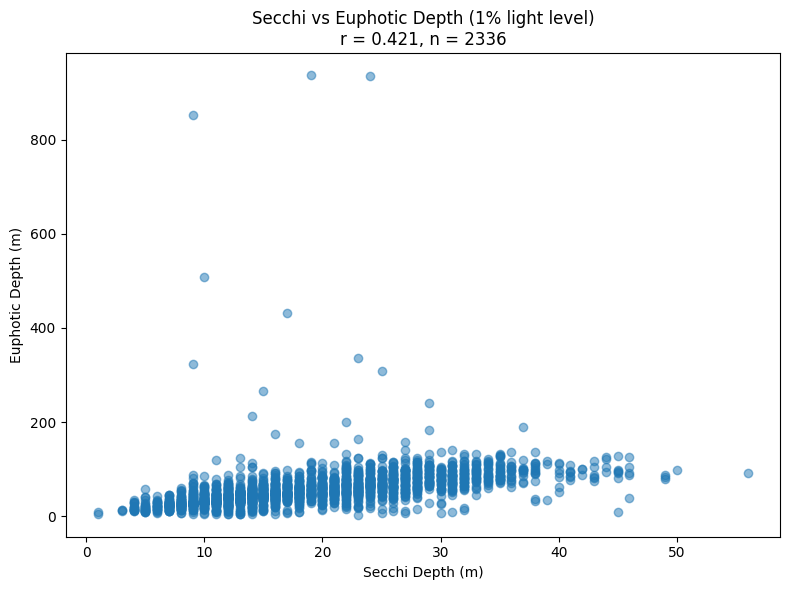

In [19]:
# Scatter plot: Secchi vs Euphotic Depth
plt.figure(figsize=(8, 6))
plt.scatter(euphotic_df['Secchi'], euphotic_df['euphotic_depth'], alpha=0.5)
plt.xlabel('Secchi Depth (m)')
plt.ylabel('Euphotic Depth (m)')
plt.title(f'Secchi vs Euphotic Depth (1% light level)\nr = {corr:.3f}, n = {len(euphotic_df)}')
plt.tight_layout()
plt.show()

Euphotic depth (2m baseline) statistics (n=1911 casts):
count    1911.000000
mean       58.093489
std        34.376079
min         3.980000
25%        37.031480
50%        53.023987
75%        75.620328
max       507.540000
Name: euphotic_depth, dtype: float64

Correlation between Secchi and Euphotic Depth (2m baseline):
r = 0.5451


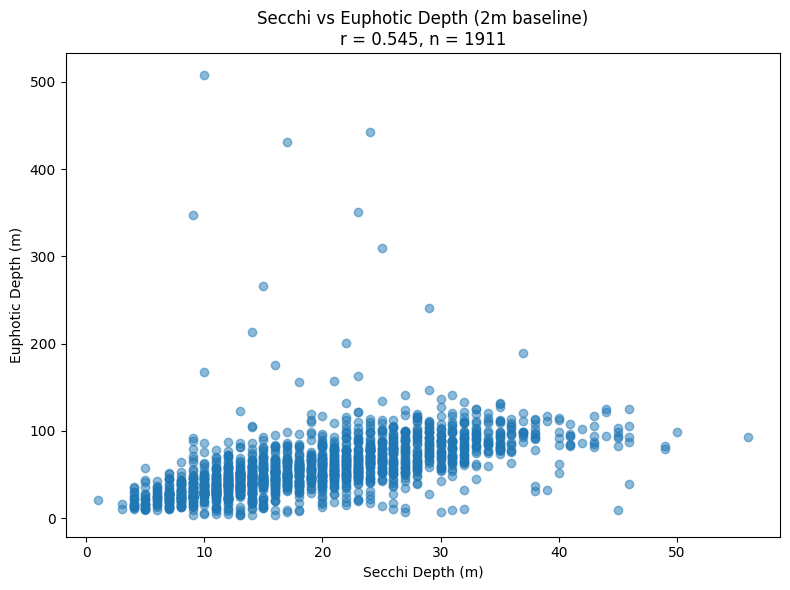

In [ ]:
# Recalculate euphotic depth using only casts with 2m as baseline depth - suggested by Rasmus
def calculate_euphotic_depth_2m(group):
    """Calculate euphotic depth using PAR at 2m depth as the surface reference."""
    # Sort by depth and drop rows with missing PAR
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    # Check if we have a measurement at exactly 2m depth
    depth_2m = group[group['DEPTH'] == 2.0]
    if len(depth_2m) == 0 or len(group) < 2:
        return np.nan
    
    # Use PAR at 2m as the surface reference
    surface_par = depth_2m['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    # Only use depths >= 2m
    group = group[group['DEPTH'] >= 2.0].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    # Find where PAR crosses 1% threshold
    above_1pct = group[group['PAR_pct'] >= 1]
    below_1pct = group[group['PAR_pct'] < 1]
    
    if len(below_1pct) == 0:
        return np.nan
    if len(above_1pct) == 0:
        return np.nan
    
    # Linear interpolation
    depth_above = above_1pct['DEPTH'].iloc[-1]
    depth_below = below_1pct['DEPTH'].iloc[0]
    par_pct_above = above_1pct['PAR_pct'].iloc[-1]
    par_pct_below = below_1pct['PAR_pct'].iloc[0]
    
    euphotic_depth = depth_above + (depth_below - depth_above) * (par_pct_above - 1) / (par_pct_above - par_pct_below)
    
    return euphotic_depth

# Calculate euphotic depth for casts with 2m baseline
euphotic_depths_2m = df.groupby('CAST_COUNT').apply(calculate_euphotic_depth_2m, include_groups=False)
euphotic_depths_2m.name = 'euphotic_depth_2m'

# Combine with Secchi for correlation
euphotic_df_2m = pd.DataFrame({'euphotic_depth': euphotic_depths_2m, 'Secchi': secchi_per_cast}).dropna()

print(f"Euphotic depth (2m baseline) statistics (n={len(euphotic_df_2m)} casts):")
print(euphotic_df_2m['euphotic_depth'].describe())

print(f"\nCorrelation between Secchi and Euphotic Depth (2m baseline):")
corr_2m = euphotic_df_2m['Secchi'].corr(euphotic_df_2m['euphotic_depth'])
print(f"r = {corr_2m:.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(euphotic_df_2m['Secchi'], euphotic_df_2m['euphotic_depth'], alpha=0.5)
plt.xlabel('Secchi Depth (m)')
plt.ylabel('Euphotic Depth (m)')
plt.title(f'Secchi vs Euphotic Depth (2m baseline)\nr = {corr_2m:.3f}, n = {len(euphotic_df_2m)}')
plt.tight_layout()
plt.show()

Suggestions from Rasmus:

Keep cholorphyll a, transmisommeter, weather stuff
Look at line and station, split up correlations including all stations 60 or less (ignore line) and stations 61+ are stations away from shore

Look at chlorophyll a and transmisometer (captures any particles passing my light beam sensor - shows decrease in light) data next week
More material --> shallower secchi depth (more productivity)
Integrate transmisometer readings within euphotic zone calcualtiosn/correlaitnos
